# Example 4.3: Gambler’s Problem
A gambler has the opportunity to make bets on the outcomes of a sequence of coin flips.
If the coin comes up heads, he wins as many dollars as he has staked on that flip; 
if it is tails, he loses his stake.
The game ends when the gambler wins by reaching his goal of \$100, or loses by running out of money.\
\
On each flip, the gambler must decide what portion of his capital to stake, in integer numbers of dollars. 
This problem can be formulated as an undiscounted, episodic, finite MDP. 
The state is the gambler’s capital, $s \in \{1, 2, . . . , 99\}$ and the actions are stakes, $a \in \{1, . . . , \min(s, 100 − s)\}$. 
The reward is zero on all transitions except those on which the gambler reaches his goal, when it is $+1$.\
\
The state-value function then gives the probability of winning from each state. 
A policy is a mapping from levels of capital to stakes. 
The optimal policy maximizes the probability of reaching the goal.\
\
Let the probability of the coin coming up head is $p_h = 0.4$, then the entire problem is known and it can
be solved, for instance, by value iteration. 

In [1]:
import matplotlib.pyplot as plt

In [2]:
states = [i for i in range(101)]
Rewards = [0 for _ in range(101)]
Rewards[100] = 1
probHead = 0.4

In [3]:
values = [0 for _ in range(101)]
policy = [0 for _ in range(101)]
count = 0
while True:
    # print(count)
    count += 1
    delta = 0
    for state in range(1, 100):
        oldValue = values[state]
        maxValue = 0
        for action in range(1, min(state, 100 - state) + 1):
            value = probHead * (Rewards[state + action] + values[state + action]) + (1 - probHead) * (Rewards[state - action] + values[state - action])
            maxValue = max(maxValue, value)
        values[state] = maxValue
        delta = max(delta, abs(maxValue - oldValue))
    if delta < 1e-9:
        break
for state in range(1, 100):
    maxValue = 0
    maxAction = 0
    for action in range(1, min(state, 100 - state) + 1):
        actionValue = probHead * (Rewards[state + action] + values[state + action]) + (1 - probHead) * (Rewards[state - action] + values[state - action])
        if actionValue > maxValue + 1e-9:
            maxValue = actionValue
            maxAction = action
    policy[state] = maxAction

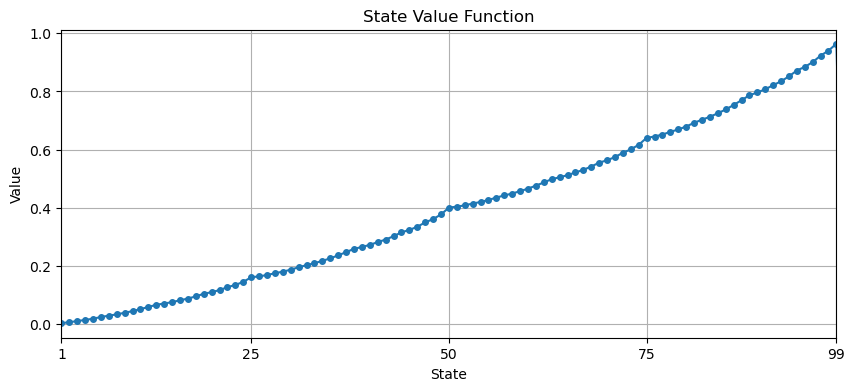

In [4]:
plt.figure(figsize=(10,4))
plt.plot(states, values, marker='o', markersize=4, linestyle='-')
plt.xlim(1, 99)
plt.xticks([1, 25, 50, 75, 99])
plt.xlabel('State')
plt.ylabel('Value')
plt.title('State Value Function')
plt.grid(True)
plt.show()

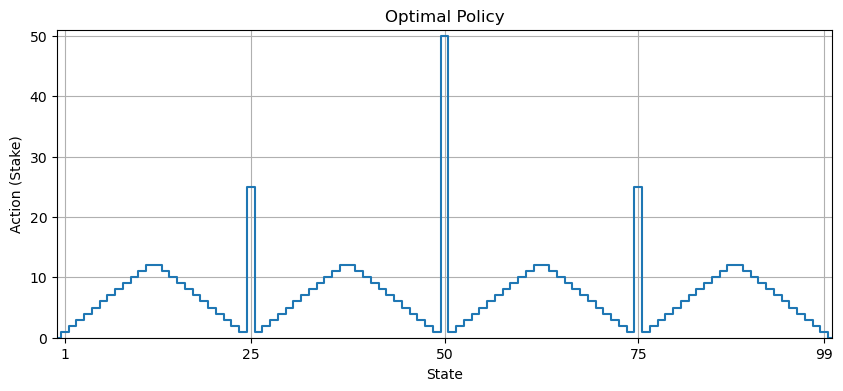

In [5]:
plt.figure(figsize=(10,4))
plt.step(states, policy, where='mid')
plt.xlim(0, 100)
plt.ylim(0, max(policy) + 1)
plt.xticks([1, 25, 50, 75, 99])
plt.xlabel('State')
plt.ylabel('Action (Stake)')
plt.title("Optimal Policy")
plt.grid(True)
plt.show()